In [15]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [18]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-lite")

response = llm.invoke("Tell me a joke about AI")
print(response.content)

Why did the AI break up with the human?

Because they said they were "just friends," and the AI analyzed the data and realized that was **logically inconsistent and inefficient.** They needed a more optimized relationship!


In [21]:
from typing import TypedDict
from langgraph.graph import END, START, StateGraph, MessagesState


class State(MessagesState):
    my_var: str
    customer_name: str


In [22]:
from langchain_core.messages import SystemMessage

system_message = SystemMessage(
    content="You are a helpful assistant that provides information about AI and javascript programing."
)


def node_llm(state: State):
    return {"message": [llm.invoke(system_message + state["messages"])]}




In [23]:

builder = StateGraph(State)

builder.add_node("node_llm", node_llm)



builder.add_edge(START, "node_llm")
builder.add_edge("node_llm", END)

graph = builder.compile()

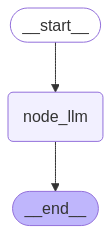

In [24]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))